In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('TSS_Ecommerce_Dataset.csv', encoding='latin1')
df.head()

,Date,Order Time,Order ID,Order Status,Customer ID,Customer Gender,Customer Age Group,City,Product Category,Product Name,...,Delivery Time (Days),Return Request,Return Reason,Customer Rating (1-5),Review Sentiment,Inventory Status,Device Used,Traffic Source,New vs Returning Customer,Estimated Profit Margin (%)
0,26-10-2024,19:07:44,TSSPC8KHO7,Delivered,TSC6658353,Female,25-34,Jaipur,Joggers,Sunday Mood Joggers,...,7,Yes,Quality Not as Expected,3.0,Neutral,In Stock,iPhone App,Instagram,New,34.8
1,13-10-2024,13:48:15,TSSCJ4L7WDG,In Transit,TSC5238259,Male,19-24,Pune,Oversized T-Shirts,Aesthetic Coordinates Oversized Tee,...,2,No,NaN,NaN,NaN,Low Stock,Website,Influencer Marketing,New,20.1
2,28-10-2024,21:58:01,TSSNPLJVUQ1,Delivered,TSC2542200,Male,25-34,Delhi,T-Shirts,Marauders Map Tee,...,3,No,NaN,5.0,Positive,Low Stock,Android App,Influencer Marketing,Returning,28.9
3,22-10-2024,20:12:30,TSSQV41H665,In Transit,TSC6785451,Female,35-44,Other Tier-2/Tier-3 Cities,Joggers,One Piece Map Adventure Joggers,...,6,No,NaN,NaN,NaN,In Stock,Android App,Instagram,Returning,31.9
4,04-10-2024,22:23:21,TSSWEPM2U8,In Transit,TSC9875310,Male,25-34,Kolkata,Oversized T-Shirts,Originals Box Fit Drop,...,4,No,NaN,NaN,NaN,In Stock,Website,Influencer Marketing,New,26.5


In [4]:
# ============================================================
# SECTION 1 — DATA OVERVIEW & CLEANING
# ============================================================

df = pd.read_csv('TSS_Ecommerce_Dataset.csv', encoding='latin1')

# Nulls
print("\nMissing values:")
print(df.isnull().sum())

# Convert date columns
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Business rule — ratings only for Delivered orders
violations = df[df['Customer Rating (1-5)'].notna() & (df['Order Status'] != 'Delivered')]
print(f"Rating violations: {len(violations)}")


Missing values:
Date                               0
Order Time                         0
Order ID                           0
Order Status                       0
Customer ID                        0
Customer Gender                    0
Customer Age Group                 0
City                               0
Product Category                   0
Product Name                       0
Franchise/Theme                    0
Size                               0
Color                              0
Quantity Ordered                   0
Order Value (INR ?)                0
Payment Method                     0
Discount Applied (%)               0
Coupon Used                        0
Coupon Code                    31410
Delivery Partner                   0
Delivery Time (Days)               0
Return Request                     0
Return Reason                  48131
Customer Rating (1-5)          19570
Review Sentiment               19570
Inventory Status                   0
Device Used          

C:\Users\ACER\AppData\Local\Temp\ipykernel_12084\47022445.py:12: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


Total GMV       : ₹62,464,480
Avg Order Value : ₹1,041
Median Order Val: ₹850
Total Orders    : 60,000


C:\Users\ACER\AppData\Local\Temp\ipykernel_12084\4184998707.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, ax=axes[0], palette='Set2')


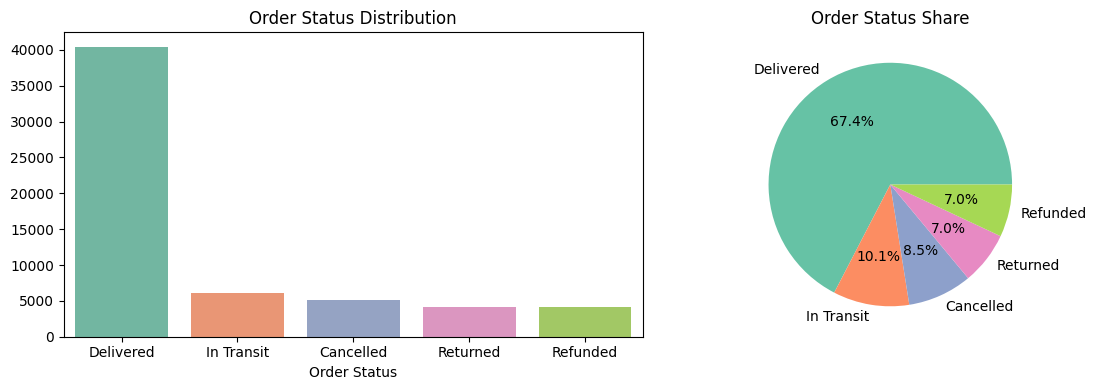

C:\Users\ACER\AppData\Local\Temp\ipykernel_12084\4184998707.py:23: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


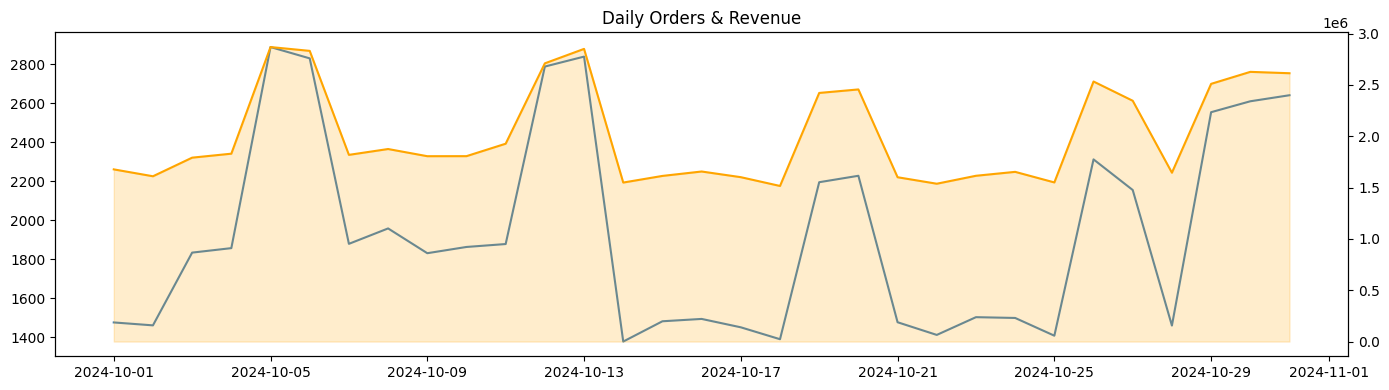

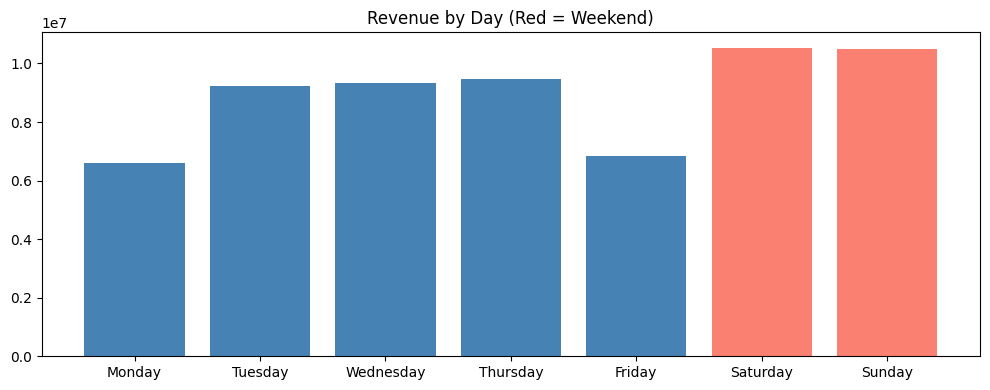


Diwali vs Non-Diwali:
                sum         mean  count
Is Diwali                              
False      54711080  1048.145140  52198
True        7753400   993.770828   7802


In [7]:
# ============================================================
# SECTION 2 — ORDER & REVENUE OVERVIEW
# ============================================================

rev = 'Order Value (INR ?)'  # corrupted ₹ symbol on your system

# 2.1 Key Metrics
print(f"Total GMV       : ₹{df[rev].sum():,.0f}")
print(f"Avg Order Value : ₹{df[rev].mean():,.0f}")
print(f"Median Order Val: ₹{df[rev].median():,.0f}")
print(f"Total Orders    : {len(df):,}")

# 2.2 Order Status Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
status_counts = df['Order Status'].value_counts()
sns.barplot(x=status_counts.index, y=status_counts.values, ax=axes[0], palette='Set2')
axes[0].set_title('Order Status Distribution')
axes[1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_title('Order Status Share')
plt.tight_layout(); plt.show()

# 2.3 Daily Order Volume + Revenue Trend
df['Date'] = pd.to_datetime(df['Date'])
daily = df.groupby('Date').agg(Orders=('Order ID','count'), Revenue=(rev,'sum')).reset_index()
fig, ax1 = plt.subplots(figsize=(14, 4))
ax1.plot(daily['Date'], daily['Orders'], color='steelblue', label='Orders')
ax2 = ax1.twinx()
ax2.fill_between(daily['Date'], daily['Revenue'], alpha=0.2, color='orange')
ax2.plot(daily['Date'], daily['Revenue'], color='orange', label='Revenue')
ax1.set_title('Daily Orders & Revenue'); plt.tight_layout(); plt.show()

# 2.4 Weekday vs Weekend
df['Day of Week'] = df['Date'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_revenue = df.groupby('Day of Week')[rev].sum().reindex(day_order)
colors = ['salmon' if d in ['Saturday','Sunday'] else 'steelblue' for d in day_order]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(day_order, day_revenue.values, color=colors)
ax.set_title('Revenue by Day (Red = Weekend)'); plt.tight_layout(); plt.show()

# 2.5 Diwali Spike (Oct 29–31)
df['Is Diwali'] = df['Date'].dt.month.eq(10) & df['Date'].dt.day.between(29, 31)
print("\nDiwali vs Non-Diwali:")
print(df.groupby('Is Diwali')[rev].agg(['sum','mean','count']))

C:\Users\ACER\AppData\Local\Temp\ipykernel_12084\2672243595.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cancel_by_pay = df.groupby('Payment Method').apply(
C:\Users\ACER\AppData\Local\Temp\ipykernel_12084\2672243595.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cancel_by_pay, x='Payment Method', y='Cancellation Rate (%)', palette='Reds_d', ax=ax)


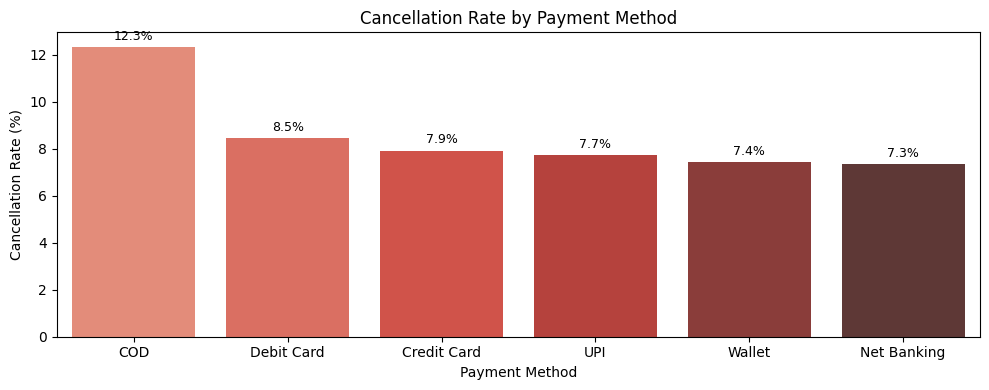

C:\Users\ACER\AppData\Local\Temp\ipykernel_12084\2672243595.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cod_city.index, y=cod_city.values, palette='Oranges_d', ax=ax)


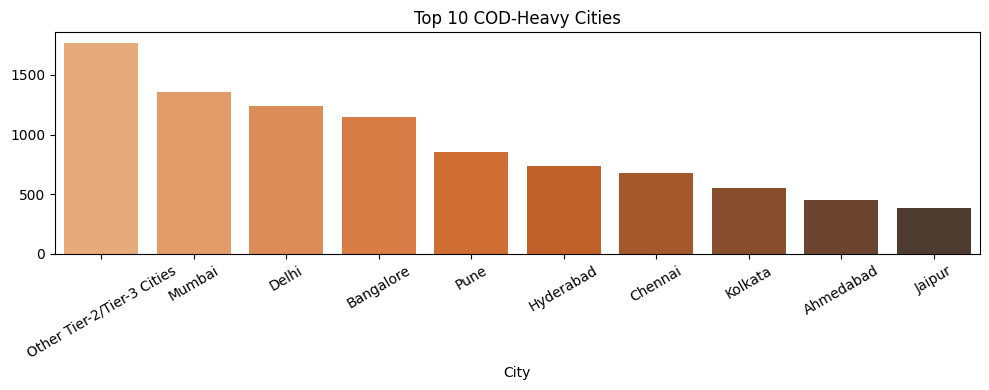

Total Revenue Lost (Cancellations) : ₹5,346,710
Lost specifically due to COD       : ₹1,226,890
COD share of cancellation loss     : 22.9%


In [9]:
# ============================================================
# SECTION 3 — COD & CANCELLATION ANALYSIS
# ============================================================

rev = 'Order Value (INR ?)'

# 3.1 Cancellation Rate by Payment Method
cancel_by_pay = df.groupby('Payment Method').apply(
    lambda x: (x['Order Status'] == 'Cancelled').sum() / len(x) * 100
).sort_values(ascending=False).reset_index()
cancel_by_pay.columns = ['Payment Method', 'Cancellation Rate (%)']

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=cancel_by_pay, x='Payment Method', y='Cancellation Rate (%)', palette='Reds_d', ax=ax)
ax.set_title('Cancellation Rate by Payment Method')
for bar, val in zip(ax.patches, cancel_by_pay['Cancellation Rate (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

# 3.2 COD Orders by City
cod_city = df[df['Payment Method'] == 'COD']['City'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=cod_city.index, y=cod_city.values, palette='Oranges_d', ax=ax)
ax.set_title('Top 10 COD-Heavy Cities')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

# 3.3 Revenue Lost to Cancellations
cancelled = df[df['Order Status'] == 'Cancelled']
total_lost = cancelled[rev].sum()
cod_lost = cancelled[cancelled['Payment Method'] == 'COD'][rev].sum()

print(f"Total Revenue Lost (Cancellations) : ₹{total_lost:,.0f}")
print(f"Lost specifically due to COD       : ₹{cod_lost:,.0f}")
print(f"COD share of cancellation loss     : {cod_lost/total_lost*100:.1f}%")

C:\Users\ACER\AppData\Local\Temp\ipykernel_12084\3503263423.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_rev.values, y=top_rev.index, palette='Blues_d', ax=ax)


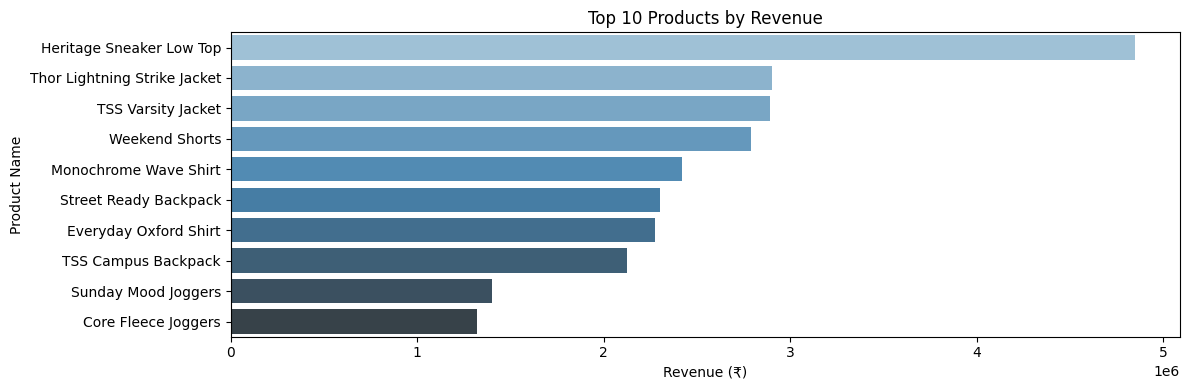

C:\Users\ACER\AppData\Local\Temp\ipykernel_12084\3503263423.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vol.values, y=top_vol.index, palette='Greens_d', ax=ax)


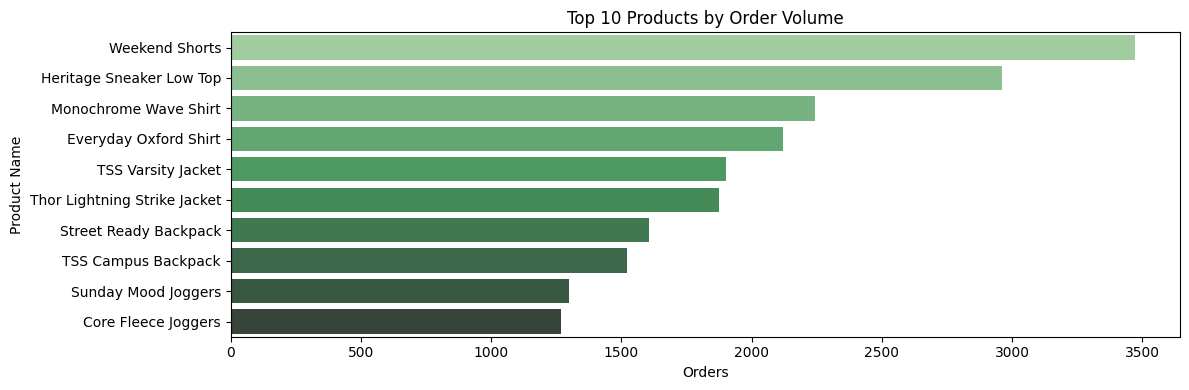

C:\Users\ACER\AppData\Local\Temp\ipykernel_12084\3503263423.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=franchise_rev.values, y=franchise_rev.index, palette='Purples_d', ax=ax)


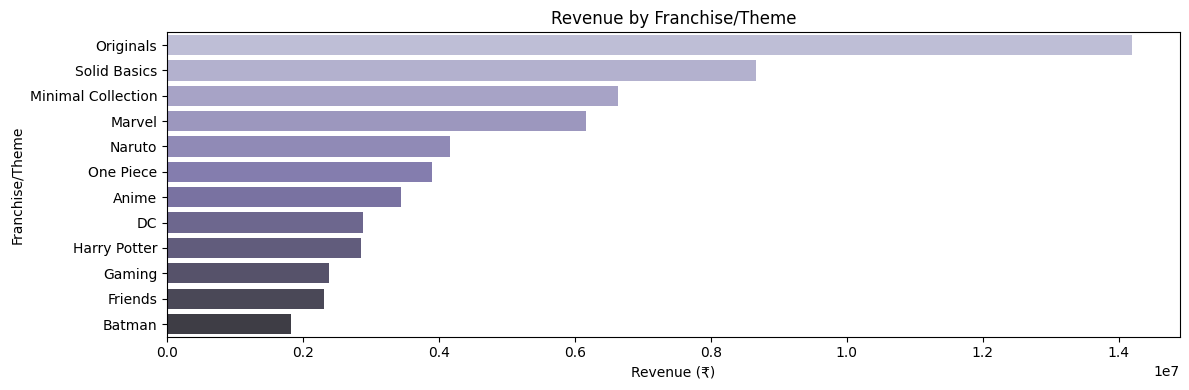

C:\Users\ACER\AppData\Local\Temp\ipykernel_12084\3503263423.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return_rate = df.groupby('Product Category').apply(
C:\Users\ACER\AppData\Local\Temp\ipykernel_12084\3503263423.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=return_rate, x='Product Category', y='Return Rate (%)', palette='Reds_d', ax=ax)


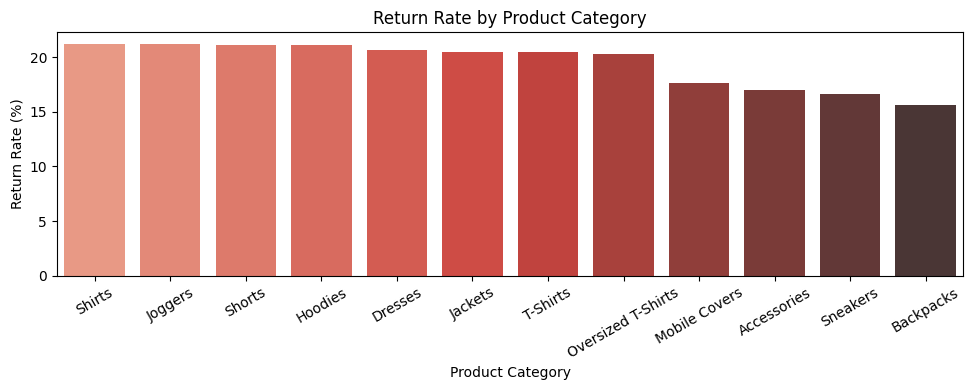

C:\Users\ACER\AppData\Local\Temp\ipykernel_12084\3503263423.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=size_counts.index, y=size_counts.values, palette='Set2', ax=ax)


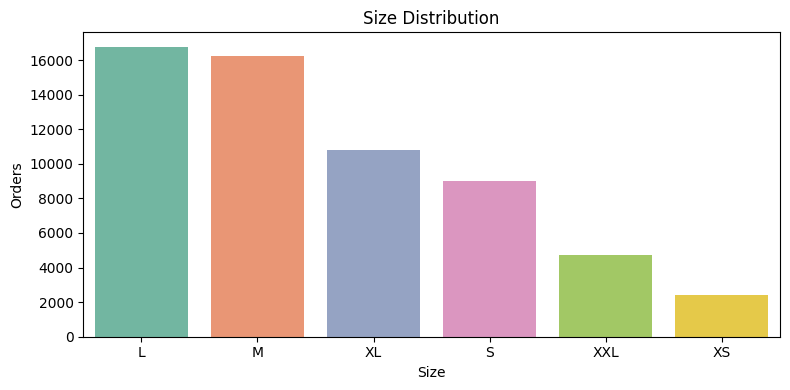

C:\Users\ACER\AppData\Local\Temp\ipykernel_12084\3503263423.py:52: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  oos = df.groupby('Franchise/Theme').apply(
C:\Users\ACER\AppData\Local\Temp\ipykernel_12084\3503263423.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=oos, x='OOS Rate (%)', y='Franchise/Theme', palette='Oranges_d', ax=ax)


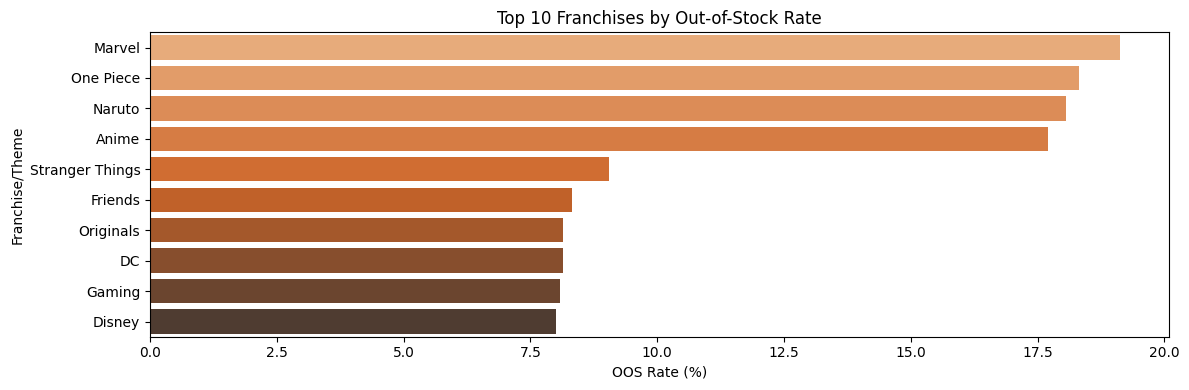

In [10]:
# ============================================================
# SECTION 6 — PRODUCT & FRANCHISE PERFORMANCE
# ============================================================

rev = 'Order Value (INR ?)'

# 6.1 Top 10 Products by Revenue
top_rev = df.groupby('Product Name')[rev].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(x=top_rev.values, y=top_rev.index, palette='Blues_d', ax=ax)
ax.set_title('Top 10 Products by Revenue')
ax.set_xlabel('Revenue (₹)')
plt.tight_layout(); plt.show()

# 6.2 Top 10 Products by Order Volume
top_vol = df['Product Name'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(x=top_vol.values, y=top_vol.index, palette='Greens_d', ax=ax)
ax.set_title('Top 10 Products by Order Volume')
ax.set_xlabel('Orders')
plt.tight_layout(); plt.show()

# 6.3 Revenue by Franchise/Theme
franchise_rev = df.groupby('Franchise/Theme')[rev].sum().sort_values(ascending=False).head(12)
fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(x=franchise_rev.values, y=franchise_rev.index, palette='Purples_d', ax=ax)
ax.set_title('Revenue by Franchise/Theme')
ax.set_xlabel('Revenue (₹)')
plt.tight_layout(); plt.show()

# 6.4 Return Rate by Product Category
return_rate = df.groupby('Product Category').apply(
    lambda x: (x['Return Request'] == 'Yes').sum() / len(x) * 100
).sort_values(ascending=False).reset_index()
return_rate.columns = ['Product Category', 'Return Rate (%)']

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=return_rate, x='Product Category', y='Return Rate (%)', palette='Reds_d', ax=ax)
ax.set_title('Return Rate by Product Category')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

# 6.5 Size Distribution
size_counts = df['Size'].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=size_counts.index, y=size_counts.values, palette='Set2', ax=ax)
ax.set_title('Size Distribution')
ax.set_ylabel('Orders')
plt.tight_layout(); plt.show()

# 6.6 Out of Stock % by Franchise
oos = df.groupby('Franchise/Theme').apply(
    lambda x: (x['Inventory Status'] == 'Out of Stock').sum() / len(x) * 100
).sort_values(ascending=False).head(10).reset_index()
oos.columns = ['Franchise/Theme', 'OOS Rate (%)']

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=oos, x='OOS Rate (%)', y='Franchise/Theme', palette='Oranges_d', ax=ax)
ax.set_title('Top 10 Franchises by Out-of-Stock Rate')
plt.tight_layout(); plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_12084\2125890827.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  band_stats = df.groupby('Discount Band')[rev].agg(['mean','sum']).reset_index()
C:\Users\ACER\AppData\Local\Temp\ipykernel_12084\2125890827.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=band_stats, x='Discount Band', y='Avg Order Value', palette='Blues_d', ax=ax)


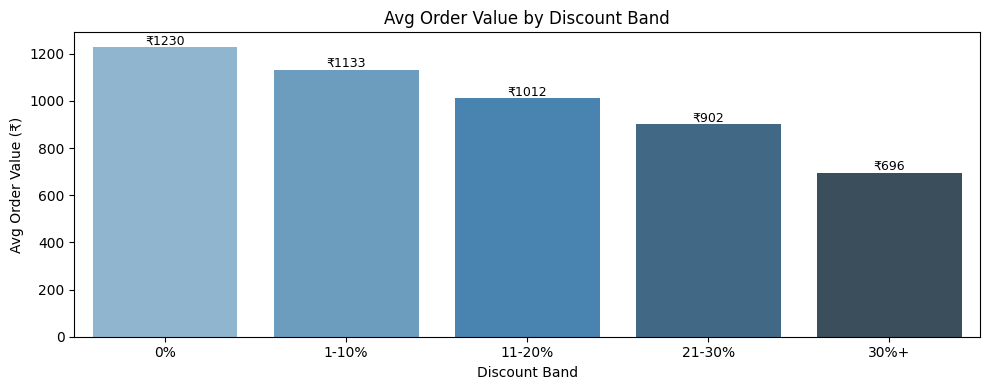

C:\Users\ACER\AppData\Local\Temp\ipykernel_12084\2125890827.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=margin, x='Product Category', y='Estimated Profit Margin (%)', palette='Greens_d', ax=ax)


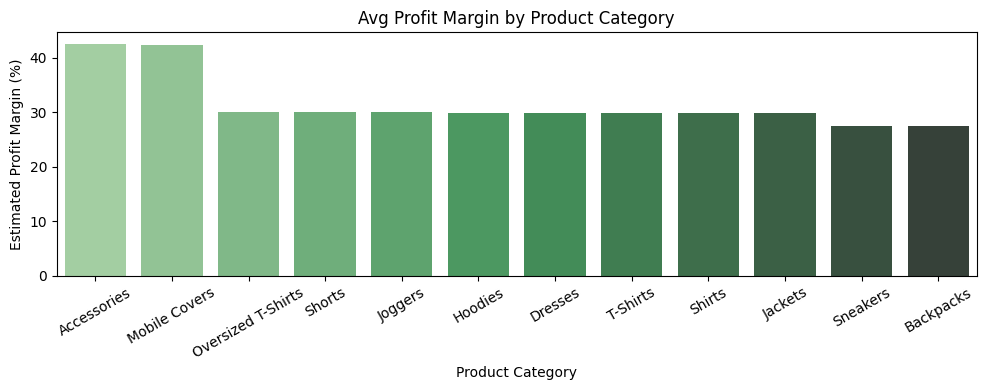

C:\Users\ACER\AppData\Local\Temp\ipykernel_12084\2125890827.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=band_stats, x='Discount Band', y='Total Revenue', palette='Oranges_d', ax=ax)


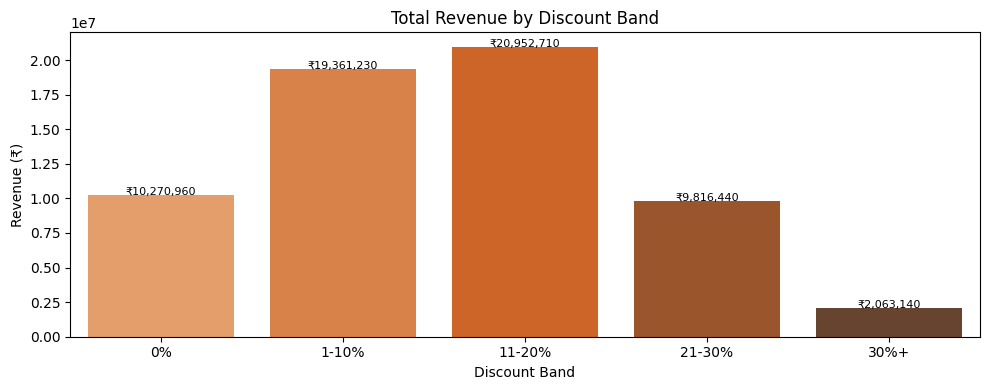

In [11]:
# ============================================================
# SECTION 4 — DISCOUNT & MARGIN ANALYSIS
# ============================================================

rev = 'Order Value (INR ?)'

# 4.1 Avg Order Value by Discount Band
bins = [-1, 0, 10, 20, 30, 100]
labels = ['0%', '1-10%', '11-20%', '21-30%', '30%+']
df['Discount Band'] = pd.cut(df['Discount Applied (%)'], bins=bins, labels=labels)

band_stats = df.groupby('Discount Band')[rev].agg(['mean','sum']).reset_index()
band_stats.columns = ['Discount Band', 'Avg Order Value', 'Total Revenue']

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=band_stats, x='Discount Band', y='Avg Order Value', palette='Blues_d', ax=ax)
ax.set_title('Avg Order Value by Discount Band')
ax.set_ylabel('Avg Order Value (₹)')
for bar, val in zip(ax.patches, band_stats['Avg Order Value']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'₹{val:.0f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

# 4.2 Profit Margin by Category
margin = df.groupby('Product Category')['Estimated Profit Margin (%)'].mean().sort_values(ascending=False).reset_index()
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=margin, x='Product Category', y='Estimated Profit Margin (%)', palette='Greens_d', ax=ax)
ax.set_title('Avg Profit Margin by Product Category')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

# 4.3 Revenue by Discount Band — are heavy discounts worth it?
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=band_stats, x='Discount Band', y='Total Revenue', palette='Oranges_d', ax=ax)
ax.set_title('Total Revenue by Discount Band')
ax.set_ylabel('Revenue (₹)')
for bar, val in zip(ax.patches, band_stats['Total Revenue']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f'₹{val:,.0f}', ha='center', fontsize=8)
plt.tight_layout(); plt.show()